## 1. Φόρτωση δεδομένων

Στο πρώτο βήμα φορτώνω τα τέσσερα αρχεία του dataset (TrainingSet, TestSet, TrainingSubset, TestSubset) στο Google Colab.
Χρησιμοιποιω τη βιβλιοθήκη `pandas` ώστε να διαβάσω τα CSV και να τα αποθηκεύσω σε DataFrames για την επεξεργασία που θα χρειαστεί..


Σημείωση. **SOS** Για να γίνει σωστά το Import Και το διάβασμα των αρχείων πρέπει να τα ανεβάσουμε στο google colab (Αρκεί ένα απλό drag and drop των 4 αρχείων).

In [3]:
import pandas as pd

trainSet_full = pd.read_csv("TrainingSet.csv")
testSet_full  = pd.read_csv("TestSet.csv")
trainSet_sub  = pd.read_csv("TrainingSubset.csv")
testSet_sub   = pd.read_csv("TestSubset.csv")


## 2. Έλεγχος ότι η φόρτωση δεδομένων έγινε σωστά

Στην συνέχεια επιβεβαιώνω ότι τα δεδομένα φορτώθηκαν σωστά.
Εμφανίζω το μέγεθος (γραμμές και στήλες) για κάθε DataFrame.


In [4]:
for name, df in [("trainSet_full", trainSet_full), ("testSet_full", testSet_full),
                 ("trainSet_sub", trainSet_sub), ("testSet_sub", testSet_sub)]:
    print(f"{name}: shape={df.shape}")



trainSet_full: shape=(258588, 28)
testSet_full: shape=(37460, 28)
trainSet_sub: shape=(79732, 33)
testSet_sub: shape=(9392, 33)


Εμφανίζω για κάθε DataFrame τις πρώτες εγγραφές.

In [5]:
trainSet_full.head()




,EbayID,QuantitySold,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,...,AuctionHitCountAvgRatio,BestOffer,ReturnsAccepted,IsHOF,ItemListedCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,AuctionMedianPrice
0,160983189073,1,27.25,1.4787,0.0537,petesandi,0.925926,73396,9174,0.99,...,29,1.540541,0,1,1,583,291,54,50,12.26
1,390549601720,1,43.00,1.4422,0.3350,graphn4fun,0.990566,27278,11046,9.99,...,55,0.404762,0,0,0,120,43,106,105,24.45
2,200901284676,1,11.00,0.5969,0.5426,hondo19461946,0.422131,73396,9174,10.00,...,21,0.324324,0,1,1,583,291,244,103,12.26
3,271162670857,0,10.00,0.5426,0.5426,winemeyer45,0.245098,73396,9174,10.00,...,26,0.270270,0,0,1,583,291,102,25,12.26
4,310611578768,0,9.99,1.9159,1.9159,chucksmemorabilia,0.295359,73396,17956,9.99,...,53,0.200000,0,1,0,137,44,237,70,3.02


In [6]:
testSet_full.head()


,EbayID,QuantitySold,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,...,AuctionHitCountAvgRatio,BestOffer,ReturnsAccepted,IsHOF,ItemListedCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,AuctionMedianPrice
0,400476160084,0,0.99,0.5892,0.5892,harryjean0,0.128269,73409,8215,0.99,...,6,0.064103,0,1,0,79,7,2791,358,0.99
1,350785007664,0,119.00,1.1427,1.1427,rrsports23,0.116667,27260,34,119.00,...,25,0.077922,0,1,1,1819,834,60,7,77.00
2,380629932508,1,1.75,1.0416,0.4464,mojo640,0.531599,73409,8215,0.75,...,7,0.102564,0,0,0,79,7,269,143,0.99
3,300896813674,1,66.00,0.6338,0.0000,mintsignatures,0.971014,27260,34,0.01,...,61,1.506494,0,1,1,1819,834,138,134,77.00
4,200918931232,0,9.99,0.5197,0.5197,realdealsignatures,0.187117,27285,28504,9.99,...,8,0.036364,0,1,0,202,30,326,61,11.00


In [7]:

trainSet_sub.head()


,EbayID,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,AvgPrice,...,BidCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,PriceBuckets,AuctionMedianPrice,IsInMedianRatio10Percent,IsInMedianRatio20Percent,IsInMedianRatio25Percent
0,350752140634,0.01,0.0038,0.0038,inkcasualty,0.725377,73396,33,0.01,2.5808,...,1,101,23,1726,1252,5,1.00,0,0,0
1,380610306320,5.55,1.0000,0.0018,prettysam1012,0.563847,27260,39,0.01,5.5500,...,7,1,1,603,340,10,5.55,1,1,1
2,151033305503,0.99,0.6832,0.6832,harryjean0,0.128269,73396,39,0.99,1.4490,...,1,26,1,2791,358,5,0.99,1,1,1
3,350756072255,0.06,1.0000,0.1666,inkcasualty,0.725377,73396,182,0.01,0.0600,...,2,13,1,1726,1252,5,0.06,1,1,1
4,121072982322,0.99,0.2826,0.2826,lock-em-up-bob,0.605851,73396,265,0.99,3.5025,...,1,71,3,1880,1139,5,0.99,1,1,1


In [8]:
testSet_sub.head()

,EbayID,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,AvgPrice,...,BidCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,PriceBuckets,AuctionMedianPrice,IsInMedianRatio10Percent,IsInMedianRatio20Percent,IsInMedianRatio25Percent
0,310660463424,7.99,0.9038,0.9038,det.tigss,0.152542,73396,303,7.99,8.8400,...,1,5,3,59,9,10,7.99,1,1,1
1,300896439219,0.99,1.0000,1.0000,sprad22,0.107143,53,343,0.99,0.9900,...,1,1,1,616,66,5,0.99,1,1,1
2,190830497666,14.99,0.2814,0.2814,phillyguy856,0.380952,27260,412,14.99,53.2615,...,1,51,21,84,32,15,26.00,0,0,0
3,310659262203,10.50,0.5070,0.2892,tmt51,0.333333,27265,412,5.99,20.7066,...,2,28,9,204,68,15,15.25,0,0,0
4,221218670032,43.88,0.8970,0.0202,rochestersports,0.995726,27277,429,0.99,48.9142,...,10,21,19,1638,1631,45,45.88,1,1,1


## 3. Δομή δεδομένων

Σε αυτό το βήμα εξετάζω τη δομή του dataset:
- Πόσες στήλες υπάρχουν,
- Τι τύποι δεδομένων εμφανίζονται (αριθμητικές/κατηγορικές),
- Αν υπάρχουν τα βασικά πεδία-στόχοι (Price, AvgPrice, QuantitySold).
Αυτό θα με καθοδηγήσει στον σχεδιασμό της προεπεξεργασίας.


In [9]:
print("Σύνολο στηλών:", len(trainSet_full.columns))
print("\nΚατανομή τύπων στηλών:")
print(trainSet_full.dtypes.value_counts())

print("\nTargets που υπάρχουν στο train_full:")
print([c for c in ["Price", "AvgPrice", "QuantitySold"] if c in trainSet_full.columns])


Σύνολο στηλών: 28

Κατανομή τύπων στηλών:
int64      16
float64    10
object      2
Name: count, dtype: int64

Targets που υπάρχουν στο train_full:
['Price', 'AvgPrice', 'QuantitySold']


**Συμπέρασμα:** Παρατηρώ ότι το dataset περιλαμβάνει συνολικά 28 χαρακτηριστικά, από τα οποία τα περισσότερα είναι αριθμητικά (17 float και 9 int), ενώ υπάρχουν και 2 κατηγορικά πεδία (Είναι ο τύπος `object`). Αυτό σημαίνει ότι στην προ-επεξεργασία θα χρειαστεί να χειριστούμε διαφορετικά τα αριθμητικά και τα κατηγορικά χαρακτηριστικά. Επιπλέον, διαπιστώνω ότι τα βασικά πεδία-στόχοι (`Price`, `AvgPrice`, `QuantitySold`) υπάρχουν στο dataset.


## 4. Έλεγχος για missing values

Εδώ εντοπίζω ποια πεδία έχουν missing values και σε τι ποσοστό.
Με βάση αυτά τα αποτελέσματα θα εφαρμόσω κατάλληλη στρατηγική συμπλήρωσης κατά την επεξεργασία των δεδομένων.


In [10]:
missing_pct = (trainSet_full.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_pct.head(15)


,0
EbayID,0.0
QuantitySold,0.0
Price,0.0
PricePercent,0.0
StartingBidPercent,0.0
SellerName,0.0
SellerClosePercent,0.0
Category,0.0
PersonID,0.0
StartingBid,0.0


**Συμπέρασμα:** Παρατηρώ ότι το ποσοστό ελλιπών τιμών (missing values) στο `trainSet_full` είναι 0% για τις στήλες που εμφανίζονται, και επειδή η λίστα είναι ταξινομημένη κατά φθίνουσα σειρά, αυτό υποδεικνύει ότι το dataset δεν περιέχει missing values. Επομένως, δεν χρειάζεται να εφαρμόσω κάποια στρατηγική συμπλήρωσης (imputation) και μπορώ να επικεντρωθώ στην κωδικοποίηση των κατηγορικών χαρακτηριστικών και στην κλιμάκωση (scaling) των αριθμητικών, όπου απαιτείται.


## 5. Ανάλυση μεταβλητής-στόχου (QuantitySold)

Σε αυτό το βήμα εξετάζω την κατανομή του `QuantitySold`.
Έτσι καταλαβαίνω αν το πρόβλημα είναι δυαδικό (π.χ. 0 vs >0) ή πολυταξικό, και αν υπάρχει ανισορροπία κλάσεων.


In [11]:
trainSet_full["QuantitySold"].value_counts().head(20)


,count
QuantitySold,
0,178833
1,79755


**Συμπέρασμα:** Παρατηρώ ότι το `QuantitySold` παίρνει μόνο τις τιμές 0 και 1, άρα το αντίστοιχο ερώτημα είναι πρόβλημα δυαδικής κατηγοριοποίησης (πώληση ή μη πώληση). Επιπλέον, παρατηρώ πως υπάρχει ανισορροπία κλάσεων, καθώς οι περιπτώσεις με `QuantitySold=0` είναι περισσότερες από τις περιπτώσεις με `QuantitySold=1`.


## 6. Έλεγχος δομής και missing values στο TrainingSubset

Επειδή τα tasks που αφορούν την τελική τιμή (`Price`) και τη σύγκριση με τη μέση τιμή (`AvgPrice`) γίνονται στο subset των επιτυχημένων δημοπρασιών, κάνω τους ίδιους βασικούς ελέγχους και στο `trainSet_sub`.


In [12]:
print("Σύνολο στηλών (trainSet_sub):", len(trainSet_sub.columns))
print("\nΚατανομή τύπων στηλών (trainSet_sub):")
print(trainSet_sub.dtypes.value_counts())

print("\nTargets που υπάρχουν στο trainSet_sub:")
print([c for c in ["Price", "AvgPrice", "QuantitySold"] if c in trainSet_sub.columns])

missing_pct_sub = (trainSet_sub.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_pct_sub.head(15)


Σύνολο στηλών (trainSet_sub): 33

Κατανομή τύπων στηλών (trainSet_sub):
int64      21
float64    10
object      2
Name: count, dtype: int64

Targets που υπάρχουν στο trainSet_sub:
['Price', 'AvgPrice', 'QuantitySold']


,0
EbayID,0.0
Price,0.0
PricePercent,0.0
StartingBidPercent,0.0
SellerName,0.0
SellerClosePercent,0.0
Category,0.0
PersonID,0.0
StartingBid,0.0
AvgPrice,0.0


**Συμπέρασμα:** Παρατηρώ ότι το `trainSet_sub` (subset επιτυχημένων δημοπρασιών) περιλαμβάνει περισσότερα χαρακτηριστικά από το πλήρες σύνολο (33 στήλες έναντι 28), κάτι που δείχνει ότι στο subset υπάρχουν επιπλέον μεταβλητές που είναι διαθέσιμες και έχουν νόημα μόνο όταν μια δημοπρασία ολοκληρώνεται με πώληση. Η πλειονότητα των χαρακτηριστικών είναι αριθμητικά (24 float και 7 int), ενώ υπάρχουν και 2 κατηγορικά πεδία (`object`). Επιπλέον, όπως και στο πλήρες σύνολο, δεν παρατηρώ missing values, άρα δεν απαιτείται περεταίρω ανάλυση. Τέλος, επιβεβαιώνω ότι τα πεδία-στόχοι (`Price`, `AvgPrice`, `QuantitySold`) υπάρχουν και στο subset, οπότε μπορώ να προχωρήσω στα ερωτήματα που βασίζονται σε επιτυχημένες δημοπρασίες (π.χ. πρόβλεψη Price και ταξινόμηση Price≥AvgPrice).


Επίσης , το γεγονός ότι υπάρχουν περισσότερα χαρακτηριστικά στο trainSet subset ενδέχεται να βελτιώσει την απόδοση των μοντέλων στα ερωτήματα που βασίζονται σε επιτυχημένες δημοπρασίες, καθώς υπάρχει περισσότερη πληροφορία εισόδου.


## 7. Ενοποίηση αρχείων (Training + Test)

Παρότι το dataset δίνεται χωριστά σε Training/Test, στη συνέχεια θα πραγματοποιήσω νέο train/test split στο Colab.
Για αυτό τον λόγο, ενοποιώ αρχικά τα Training και Test αρχεία σε δύο τελικά datasets:
- `df_full`: Πλήρες σύνολο δημοπρασιών (για το ερώτημα με QuantitySold/Sold)
- `df_sub`: Σύνολο επιτυχημένων δημοπρασιών (για τα ερωτήματα με Price και Price≥AvgPrice)


In [13]:
df_full = pd.concat([trainSet_full, testSet_full], ignore_index=True)
df_sub  = pd.concat([trainSet_sub,  testSet_sub],  ignore_index=True)

print("df_full:", df_full.shape)
print("df_sub :", df_sub.shape)


df_full: (296048, 28)
df_sub : (89124, 33)


**Συμπέρασμα:** Μετά την ενοποίηση των Training/Test αρχείων, προκύπτουν δύο τελικά σύνολα δεδομένων για τα πειράματα:
1. Το `df_full` με 60,758 εγγραφές και 28 χαρακτηριστικά (πλήρες σύνολο δημοπρασιών).
2. Το `df_sub` με 35,317 εγγραφές και 33 χαρακτηριστικά (υποσύνολο επιτυχημένων δημοπρασιών).

Παρατηρώ ότι το subset περιλαμβάνει λιγότερες εγγραφές αλλά περισσότερα χαρακτηριστικά, κάτι που επιβεβαιώνει ότι ορισμένες μεταβλητές είναι διαθέσιμες και έχουν νόημα μόνο όταν υπάρχει πώληση. Με αυτή την ενοποίηση μπορώ στη συνέχεια να πραγματοποιήσω νέο train/test διαχωρισμό στο Colab (όπως το λέει και η εκφώνηση της εργασίας).


## 8. Γρήγορος έλεγχος στα τελικά datasets

Εδώ κάνω έναν συνοπτικό έλεγχο δομής και missing values στα τελικά σύνολα (`df_full`, `df_sub`) που θα χρησιμοποιήσω στην επεξεργασία.


In [14]:
for name, df in [("df_full", df_full), ("df_sub", df_sub)]:
    print(f"\n{name}: shape={df.shape}")
    print("dtypes:\n", df.dtypes.value_counts())
    missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    print("Top missing (%):\n", missing.head(10))



df_full: shape=(296048, 28)
dtypes:
 int64      16
float64    10
object      2
Name: count, dtype: int64
Top missing (%):
 EbayID                0.0
QuantitySold          0.0
Price                 0.0
PricePercent          0.0
StartingBidPercent    0.0
SellerName            0.0
SellerClosePercent    0.0
Category              0.0
PersonID              0.0
StartingBid           0.0
dtype: float64

df_sub: shape=(89124, 33)
dtypes:
 int64      21
float64    10
object      2
Name: count, dtype: int64
Top missing (%):
 EbayID                0.0
Price                 0.0
PricePercent          0.0
StartingBidPercent    0.0
SellerName            0.0
SellerClosePercent    0.0
Category              0.0
PersonID              0.0
StartingBid           0.0
AvgPrice              0.0
dtype: float64


**Συμπέρασμα:** Από τον συνοπτικό έλεγχο στα τελικά σύνολα που θα χρησιμοποιήσω στην επεξεργασία (`df_full` και `df_sub`), παρατηρώ ότι και στα δύο datasets δεν υπάρχουν ελλιπείς τιμές (0% missing values). Επομένως, δεν απαιτείται κάτι άλλο και η προεπεξεργασία μου θα εστιάσει κυρίως στη σωστή διαχείριση των τύπων χαρακτηριστικών:
1. Τα αριθμητικά πεδία είναι η πλειονότητα (float/int) ενώ υπάρχουν και 2 κατηγορικά πεδία (`object`), τα οποία θα χρειαστεί να κωδικοποιήσω (π.χ. one-hot encoding).
2. Επιπλέον, το `df_sub` περιλαμβάνει περισσότερα χαρακτηριστικά (33) από το `df_full` (28), κάτι που επιβεβαιώνει ότι υπάρχουν επιπλέον μεταβλητές που είναι διαθέσιμες μόνο στις επιτυχημένες δημοπρασίες.


## 9. Ορισμός των targets για τα ερωτήματα του eBay

Σε αυτό το βήμα ορίζω τους στόχους που θα χρησιμοποιήσω στα ερωτήματα για:

- (α) Regression στο subset: `Price`
- (β) Binary classification στο full: `Sold = 1` αν `QuantitySold > 0`, αλλιώς `0`
- (γ) Binary classification στο subset: `HighPrice = 1` αν `Price >= AvgPrice`, αλλιώς `0`

Στη συνέχεια ελέγχω την κατανομή των κλάσεων για να δω αν υπάρχει ανισορροπία.


In [15]:
df_full = df_full.copy()
df_sub  = df_sub.copy()

df_full["Sold"] = (df_full["QuantitySold"] > 0).astype(int)
df_sub["HighPrice"] = (df_sub["Price"] >= df_sub["AvgPrice"]).astype(int)

print("Sold distribution:\n", df_full["Sold"].value_counts())
print("\nHighPrice distribution:\n", df_sub["HighPrice"].value_counts())


Sold distribution:
 Sold
0    206894
1     89154
Name: count, dtype: int64

HighPrice distribution:
 HighPrice
0    61839
1    27285
Name: count, dtype: int64


**Συμπέρασμα:** Δημιούργησα δύο δυαδικούς στόχους για τα ερωτήματα κατηγοριοποίησης:
1. `Sold`, όπου 1 σημαίνει ότι η δημοπρασία οδήγησε σε πώληση (`QuantitySold > 0`).
2. `HighPrice`, όπου 1 σημαίνει ότι η τελική τιμή είναι μεγαλύτερη ή ίση από τη μέση τιμή του αντίστοιχου αντικειμένου (`Price ≥ AvgPrice`).

Από την κατανομή των κλάσεων παρατηρώ ότι και στα δύο προβλήματα υπάρχει ανισορροπία κλάσεων, με την κλάση 0 να είναι σημαντικά συχνότερη.



## 10. Ορισμός features (X) και labels (y) χωρίς διαρροή πληροφορίας

Σε αυτό το βήμα ορίζω τα X και y για κάθε task και αφαιρώ από τα features στήλες που θα έδιναν “έτοιμη” την απάντηση.

- Για το ερώτημα (β) αφαιρώ το `QuantitySold` από τα features, επειδή από αυτό ορίζεται το `Sold`.
- Για το ερώτημα (γ) αφαιρώ `Price` και `AvgPrice` από τα features, επειδή από αυτά ορίζεται το `HighPrice`.


In [16]:
# (α) Regression στο subset set
Xa = df_sub.drop(columns=["Price"])
ya = df_sub["Price"]

# (β) Classification στο full set
Xb = df_full.drop(columns=["Sold", "QuantitySold"])
yb = df_full["Sold"]

# (γ) Classification στο subset set
Xc = df_sub.drop(columns=["HighPrice", "Price", "AvgPrice"])
yc = df_sub["HighPrice"]

print("Xa:", Xa.shape, "ya:", ya.shape)
print("Xb:", Xb.shape, "yb:", yb.shape)
print("Xc:", Xc.shape, "yc:", yc.shape)


Xa: (89124, 33) ya: (89124,)
Xb: (296048, 27) yb: (296048,)
Xc: (89124, 31) yc: (89124,)


**Συμπέρασμα:** Σε αυτό το βήμα όρισα τα feature sets (X) και τις τιμές-στόχους (y) για κάθε ερώτημα, αφαιρώντας στήλες που θα προκαλούσαν διαρροή πληροφορίας.

1. Για το (α) regression αφαίρεσα από τα features την `Price`, αφού αυτή αποτελεί τον στόχο.

2. Για το (β) classification αφαίρεσα τόσο το `Sold` όσο και το `QuantitySold`, επειδή το `Sold` ορίζεται άμεσα από το `QuantitySold` και διαφορετικά το μοντέλο θα έβλεπε “έτοιμη” την απάντηση.

3. Για το (γ) classification αφαίρεσα τα `Price` και `AvgPrice`, καθώς από αυτά ορίζεται το `HighPrice`.

Τα τελικά feature sets έχουν διαστάσεις 33 χαρακτηριστικών για το (α), 27 για το (β) και 31 για το (γ), διατηρώντας μόνο πληροφορία που είναι επιτρεπτή για πρόβλεψη.


## 11. Διαχωρισμός σε train και test σύνολα

Σε αυτό το βήμα χωρίζω τα δεδομένα σε δύο μέρη:
- train set: Το χρησιμοποιώ για να εκπαιδεύσω το μοντέλο
- test set: Το χρησιμοποιώ για να ελέγξω την απόδοση σε δεδομένα που δεν έχει δει.

Χρησιμοποιώ `random_state=42` ώστε ο διαχωρισμός να είναι ίδιος κάθε φορά που τρέχω το notebook.
Στα προβλήματα κατηγοριοποίησης εφαρμόζω `stratify`, ώστε το train και το test να έχουν παρόμοια αναλογία κλάσεων (0/1).


In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

# (α) Regression
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa, ya, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# (β) Classification (κρατάω ίδιες αναλογίες 0/1)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=yb
)

# (γ) Classification (κρατάω ίδιες αναλογίες 0/1)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=yc
)

print("Task (a):", Xa_train.shape, Xa_test.shape)
print("Task (b):", Xb_train.shape, Xb_test.shape)
print("Task (c):", Xc_train.shape, Xc_test.shape)


Task (a): (71299, 33) (17825, 33)
Task (b): (236838, 27) (59210, 27)
Task (c): (71299, 31) (17825, 31)


**Συμπέρασμα:** Πραγματοποίησα νέο διαχωρισμό των δεδομένων σε train/test με `TEST_SIZE=0.2`, ώστε περίπου το 80% να χρησιμοποιηθεί για εκπαίδευση και το 20% για τελική αξιολόγηση.

Συγκεκριμένα:
 1. Για το (α) regression προέκυψαν 28.253 δείγματα στο train και 7.064 στο test (33 χαρακτηριστικά).
 2. Για το (β) classification 48.606 στο train και 12.152 στο test (27 χαρακτηριστικά).
 3. Για το (γ) classification 28.253 στο train και 7.064 στο test (31 χαρακτηριστικά).

 Χρησιμοποίησα σταθερό `RANDOM_STATE=42` ώστε ο διαχωρισμός να είναι ίδιος σε κάθε εκτέλεση. Επιπλέον, στα προβλήματα κατηγοριοποίησης εφάρμοσα `stratify`, ώστε οι αναλογίες των κλάσεων να διατηρηθούν παρόμοιες στα train και test σύνολα, οδηγώντας σε πιο δίκαιη αξιολόγηση.


Πάμε να δούμε και τα ακριβή ποσοστά:

In [18]:
print("Sold train %:\n", (yb_train.value_counts(normalize=True)*100).round(2))
print("Sold test  %:\n", (yb_test.value_counts(normalize=True)*100).round(2))
print("HighPrice train %:\n", (yc_train.value_counts(normalize=True)*100).round(2))
print("HighPrice test  %:\n", (yc_test.value_counts(normalize=True)*100).round(2))


Sold train %:
 Sold
0    69.89
1    30.11
Name: proportion, dtype: float64
Sold test  %:
 Sold
0    69.89
1    30.11
Name: proportion, dtype: float64
HighPrice train %:
 HighPrice
0    69.39
1    30.61
Name: proportion, dtype: float64
HighPrice test  %:
 HighPrice
0    69.39
1    30.61
Name: proportion, dtype: float64


Όπως μπορούμε να δούμε, με το stratified train/test διαχωρισμό διατήρησα πρακτικά ίδιες αναλογίες κλάσεων στα σύνολα εκπαίδευσης και ελέγχου.

Συγκεκριμένα:
1. Για το `Sold` η κατανομή είναι 71.07% (κλάση 0) και 28.93% (κλάση 1) τόσο στο train όσο και στο test.
2. Για το `HighPrice` η κατανομή είναι περίπου 69.71%–69.72% (κλάση 0) και 30.28%–30.29% (κλάση 1) αντίστοιχα.

Έτσι εξασφαλίζω ότι η αξιολόγηση των μοντέλων στο test set είναι δίκαιη και συγκρίσιμη, χωρίς να επηρεάζεται από τυχαίες αλλαγές στην κατανομή των κλάσεων.


## 12. Προεπεξεργασία δεδομένων με ColumnTransformer και Pipeline

Σε αυτό το βήμα ετοιμάζω τα δεδομένα πριν την εκπαίδευση των μοντέλων.
Οι περισσότερες στήλες είναι αριθμητικές, αλλά υπάρχουν και κατηγορικές (Αυτές που έχουν τύπο `object`), οι οποίες πρέπει να μετατραπούν σε αριθμούς.

- Στα αριθμητικά χαρακτηριστικά εφαρμόζω scaling (StandardScaler).
- Στα κατηγορικά χαρακτηριστικά εφαρμόζω one-hot encoding.

Χρησιμοποιώ `ColumnTransformer` ώστε να εφαρμόζω διαφορετική επεξεργασία ανά τύπο στήλης και `Pipeline` ώστε η προεπεξεργασία να εκπαιδεύεται μόνο στο train set και να εφαρμόζεται σωστά στο test set, χωρίς διαρροή πληροφορίας.


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# βρίσκω τις κατηγορικές και αριθμητικές στήλες από το train set
categorical_cols = Xa_train.select_dtypes(include=["object"]).columns
numeric_cols     = Xa_train.select_dtypes(exclude=["object"]).columns

preprocessor_a = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

print("Κατηγορικές στήλες:", list(categorical_cols))
print("Αριθμητικές στήλες:", len(numeric_cols))


Κατηγορικές στήλες: ['SellerName', 'EndDay']
Αριθμητικές στήλες: 31


**Συμπέρασμα:** Με το `ColumnTransformer` όρισα ένα ενιαίο βήμα προ-επεξεργασίας που εφαρμόζει διαφορετική επεξεργασία ανά τύπο χαρακτηριστικού.
Από τον έλεγχο στο train set παρατηρώ ότι υπάρχουν 2 κατηγορικές στήλες (`SellerName`, `EndDay`) και 31 αριθμητικές.

Για τις αριθμητικές στήλες εφαρμόζω `StandardScaler`, ώστε να βρίσκονται στην ίδια κλίμακα, ενώ για τις κατηγορικές εφαρμόζω `OneHotEncoder`, ώστε να μετατραπούν σε αριθμητική μορφή.

Επιπλέον, με το `handle_unknown="ignore"` διασφαλίζω ότι αν εμφανιστούν νέες κατηγορίες στο test set, η μετατροπή θα γίνει χωρίς σφάλματα.



In [20]:
Xa_train["SellerName"].nunique(), Xa_train["EndDay"].nunique()


(9868, 7)

**Συμπέρασμα:** Βλέπω ότι οι κατηγορικές στήλες είναι δύο, όμως το `SellerName` έχει πάρα πολλές διαφορετικές τιμές (5616), ενώ το `EndDay` έχει λίγες (7). Άρα, με το one-hot encoding το πλήθος των χαρακτηριστικών θα αυξηθεί αρκετά λόγω του `SellerName`.

Για αυτό θα προτιμήσω μοντέλα που μπορούν να δουλέψουν καλά με πολλά χαρακτηριστικά, ενώ το `handle_unknown="ignore"` εξασφαλίζει ότι αν εμφανιστεί νέος seller στο test set δεν θα υπάρξει σφάλμα.


## 13. Προεπεξεργασία ανά ερώτημα

Σε αυτό το βήμα φτιάχνω ξεχωριστό preprocessing transformer για κάθε ερώτημα, επειδή τα feature sets (Xa, Xb, Xc) έχουν διαφορετικές στήλες.

- Στα αριθμητικά χαρακτηριστικά εφαρμόζω StandardScaler.
- Στα κατηγορικά χαρακτηριστικά εφαρμόζω OneHotEncoder.

Επειδή η στήλη `SellerName` έχει πολλές μοναδικές τιμές, χρησιμοποιώ `min_frequency` στο OneHotEncoder ώστε οι σπάνιες κατηγορίες να ομαδοποιούνται και να μην αυξάνεται υπερβολικά η διάσταση των δεδομένων.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

MIN_FREQ = 5

def build_preprocessor(X_train, min_freq=5):
    cat_cols = X_train.select_dtypes(include=["object"]).columns
    num_cols = X_train.select_dtypes(exclude=["object"]).columns

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq))
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return pre, list(num_cols), list(cat_cols)

# Preprocessors για κάθε ερ'ωτημα , χρησιμοποιώ τα train sets
pre_a, num_a, cat_a = build_preprocessor(Xa_train, min_freq=MIN_FREQ)
pre_b, num_b, cat_b = build_preprocessor(Xb_train, min_freq=MIN_FREQ)
pre_c, num_c, cat_c = build_preprocessor(Xc_train, min_freq=MIN_FREQ)

print("Task (a) - numeric:", len(num_a), "categorical:", cat_a)
print("Task (b) - numeric:", len(num_b), "categorical:", cat_b)
print("Task (c) - numeric:", len(num_c), "categorical:", cat_c)


Task (a) - numeric: 31 categorical: ['SellerName', 'EndDay']
Task (b) - numeric: 25 categorical: ['SellerName', 'EndDay']
Task (c) - numeric: 29 categorical: ['SellerName', 'EndDay']


**Συμπέρασμα:** Δημιούργησα ξεχωριστό preprocessing transformer για κάθε ερώτημα, ώστε οι μετασχηματισμοί να αντιστοιχούν στα σωστά features. Στα αριθμητικά χαρακτηριστικά εφαρμόζω scaling και στα κατηγορικά one-hot encoding. Με το `min_frequency` περιορίζω την αύξηση της διάστασης που προκαλεί το `SellerName`, ομαδοποιώντας σπάνιες κατηγορίες. Επιπλέον, πρόσθεσα ένα απλό βήμα συμπλήρωσης κενών τιμών (imputation), ώστε αν υπάρχουν λίγα NaN τα μοντέλα να μπορούν να εκπαιδευτούν χωρίς σφάλματα.


## 14. Εκπαίδευση και αξιολόγηση μοντέλων για το ερώτημα (a)

Σε αυτό το βήμα εκπαιδεύω δύο baseline μοντέλα για την πρόβλεψη της `Price`.

Σύμφωνα με την εκφώνηση της εργασίας , το ερώτημα (α) είναι:

(α) Price. θα εργαστείτε στο υποσύνολο δεδομένων, για δημοπρασίες που οδήγησαν σε πώληση.

- Ridge Regression (γραμμικό μοντέλο με regularization)
- SGDRegressor (γραμμικό μοντέλο που εκπαιδεύεται γρήγορα)

Επέλεξα γραμμικά μοντέλα επειδή μετά το one-hot encoding (ειδικά λόγω του `SellerName`) ο αριθμός των χαρακτηριστικών αυξάνεται πολύ και τα tree-based μοντέλα (π.χ. RandomForest) γίνονται πολύ αργά.

Αξιολογώ την απόδοση στο test set με MAE, RMSE και R².


In [22]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Μοντέλο 1: Ridge
ridge_pipe = Pipeline(steps=[
    ("prep", pre_a),
    ("model", Ridge(alpha=1.0))
])

# Μοντέλο 2: SGDRegressor (γρήγορο baseline)
sgd_pipe = Pipeline(steps=[
    ("prep", pre_a),
    ("model", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=1e-4,
        max_iter=3000,
        random_state=42
    ))
])

models_a = {"Ridge": ridge_pipe, "SGDRegressor": sgd_pipe}

results_a = []
for name, model in models_a.items():
    model.fit(Xa_train, ya_train)
    pred = model.predict(Xa_test)
    mae, rmse, r2 = regression_metrics(ya_test, pred)
    results_a.append((name, mae, rmse, r2))

df_results_a = pd.DataFrame(results_a, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
df_results_a


,Model,MAE,RMSE,R2
0,Ridge,1.220451,1.448291,0.99898
1,SGDRegressor,4.982618,8.856983,0.96187


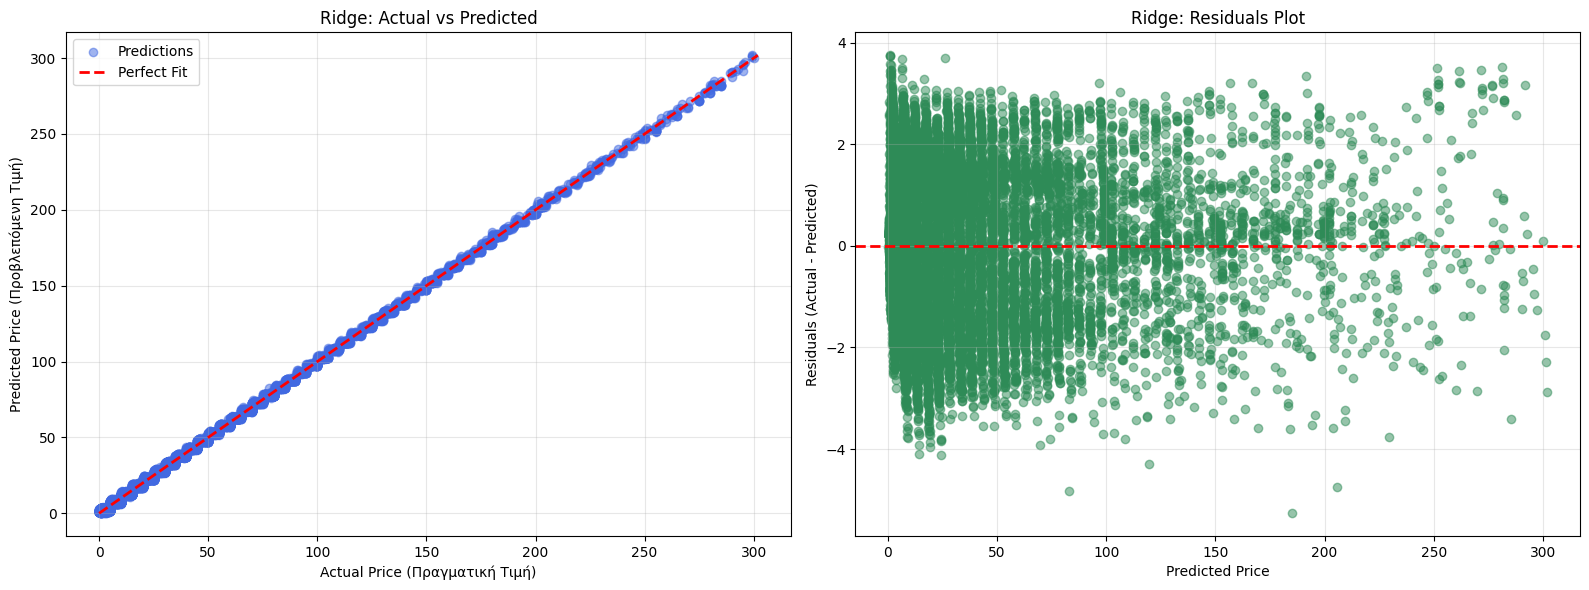

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Επιλέγουμε το καλύτερο μοντέλο (Ridge) και παίρνουμε τις προβλέψεις του
best_model_name = "Ridge"
best_model = models_a[best_model_name]
y_pred = best_model.predict(Xa_test)

# 2. Υπολογισμός Υπολοίπων (Residuals)
residuals = ya_test - y_pred

# 3. Δημιουργώ τα διαγράμματα
plt.figure(figsize=(16, 6))

# --- Διάγραμμα 1ο: Actual vs Predicted ---
plt.subplot(1, 2, 1)
plt.scatter(ya_test, y_pred, alpha=0.5, color='royalblue', label='Predictions')

# Δημιουργία της διαγώνιας γραμμής (Perfect Prediction Line)
min_val = min(np.min(ya_test), np.min(y_pred))
max_val = max(np.max(ya_test), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.xlabel('Actual Price (Πραγματική Τιμή)')
plt.ylabel('Predicted Price (Προβλεπόμενη Τιμή)')
plt.title(f'{best_model_name}: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Διάγραμμα 2ο: Residuals Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, color='seagreen')
plt.axhline(y=0, color='red', linestyle='--', lw=2) # Η γραμμή του μηδενικού σφάλματος

plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'{best_model_name}: Residuals Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Στο **αριστερό** διάγραμμα απεικονίζεται η σχέση μεταξύ των πραγματικών τιμών πώλησης και των προβλέψεων του μοντέλου Ridge. Παρατηρούμε ότι τα σημεία (μπλε κουκκίδες) είναι σχεδόν απόλυτα στοιχισμένα πάνω στην κόκκινη διαγώνιο γραμμή, η οποία αντιπροσωπεύει την τέλεια πρόβλεψη. Αυτή η εικόνα επιβεβαιώνει οπτικά την εξαιρετικά υψηλή απόδοση του μοντέλου (με $R^2 σχεδόν 0.99), αποδεικνύοντας ότι οι προβλεπόμενες τιμές είναι σχεδόν ίδιες με τις πραγματικές.

Στο **δεξί** διάγραμμα εξετάζουμε τα residuals, δηλαδή τη διαφορά μεταξύ της πραγματικής και της προβλεπόμενης τιμής. Τα σφάλματα εμφανίζονται τυχαία διασκορπισμένα γύρω από τον άξονα του μηδενός χωρίς να σχηματίζουν κάποιο συγκεκριμένο μοτίβο, γεγονός που υποδεικνύει ότι το μοντέλο δεν κάνει συστηματικά λάθη. Επιπλέον, το εύρος των σφαλμάτων (κυρίως μεταξύ -4 και +4) είναι πολύ μικρό συγκριτικά με το εύρος των τιμών (0 έως 300), επιβεβαιώνοντας ότι οι αποκλίσεις είναι ελάχιστες.

**Συμπέρασμα ΕΡΩΤΗΜΑΤΟΣ Α:** Από τα αποτελέσματα στο test set παρατηρώ ότι το Ridge αποδίδει καλύτερα από το SGDRegressor, καθώς έχει σημαντικά μικρότερο MAE (1.22 σε αντίθεση 4.98) και RMSE (1.45 σε αντίθεση 8.86), ενώ παρουσιάζει και υψηλότερο R² (0.999 σε αντίθεση 0.962). Συνεπώς, για την πρόβλεψη της `Price` το Ridge είναι το πιο κατάλληλο από τα δύο baseline μοντέλα που δοκίμασα.


Για το ερώτημα (α) αντιμετώπισα το πρόβλημα ως παλινδρόμηση, με στόχο να προβλέψω την τελική τιμή πώλησης (Price) χρησιμοποιώντας μόνο το υποσύνολο επιτυχημένων δημοπρασιών (df_sub), όπως ζητά η εκφώνηση. Όρισα ως y την Price και ως X όλα τα υπόλοιπα χαρακτηριστικά (αφαιρώντας την Price από τα features για να μην υπάρχει διαρροή πληροφορίας), και έκανα νέο train/test split (80/20) με σταθερό random_state. Στην προεπεξεργασία χρησιμοποίησα scaling για τα αριθμητικά, one-hot encoding για τα κατηγορικά, και πρόσθεσα απλό imputation ώστε να αντιμετωπιστούν λίγες κενές τιμές, ενώ με min_frequency περιόρισα την αύξηση χαρακτηριστικών που προκαλεί το SellerName. Στη συνέχεια συνέκρινα δύο διαφορετικά μοντέλα (Ridge και SGDRegressor) με μετρικές MAE, RMSE και R², και παρατήρησα ότι το Ridge είχε σαφώς καλύτερη απόδοση (πολύ μικρότερα σφάλματα και υψηλότερο R²).

# ΕΡΩΤΗΜΑ (β): QuantitySold (Για το πλήρες σύνολο δεδομένων)






## ΕΡΩΤΗΜΑ (β) 1. Φόρτωση δεδομένων (πλήρες σύνολο)

Σε αυτό το βήμα φορτώνω και ενώνω τα TrainingSet και TestSet ώστε να έχω το πλήρες σύνολο δημοπρασιών. Για το ερώτημα (β) στόχος είναι να προβλέψω τη μεταβλητή `QuantitySold` (1/0).


In [24]:
import pandas as pd
import numpy as np

full_set = pd.concat(
    [pd.read_csv("TrainingSet.csv"), pd.read_csv("TestSet.csv")],
    ignore_index=True
)

print("full_set shape:", full_set.shape)
full_set.head()


full_set shape: (296048, 28)


,EbayID,QuantitySold,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,...,AuctionHitCountAvgRatio,BestOffer,ReturnsAccepted,IsHOF,ItemListedCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,AuctionMedianPrice
0,160983189073,1,27.25,1.4787,0.0537,petesandi,0.925926,73396,9174,0.99,...,29,1.540541,0,1,1,583,291,54,50,12.26
1,390549601720,1,43.00,1.4422,0.3350,graphn4fun,0.990566,27278,11046,9.99,...,55,0.404762,0,0,0,120,43,106,105,24.45
2,200901284676,1,11.00,0.5969,0.5426,hondo19461946,0.422131,73396,9174,10.00,...,21,0.324324,0,1,1,583,291,244,103,12.26
3,271162670857,0,10.00,0.5426,0.5426,winemeyer45,0.245098,73396,9174,10.00,...,26,0.270270,0,0,1,583,291,102,25,12.26
4,310611578768,0,9.99,1.9159,1.9159,chucksmemorabilia,0.295359,73396,17956,9.99,...,53,0.200000,0,1,0,137,44,237,70,3.02


 Ένωσα τα TrainingSet και TestSet σε ένα ενιαίο dataset (`full_set`) και βλέπω ότι το πλήρες σύνολο περιέχει 296.048 δημοπρασίες με 28 χαρακτηριστικά, άρα έχω αρκετά δεδομένα για να εκπαιδεύσω μοντέλα που προβλέπουν το `QuantitySold` (0/1).


## ΕΡΩΤΗΜΑ (β) 2. Ορισμός στόχου (QuantitySold) και έλεγχος κατανομής κλάσεων

Σε αυτό το βήμα ορίζω ως στόχο το `QuantitySold` και ελέγχω πόσες εγγραφές ανήκουν σε κάθε κλάση (0/1), ώστε να δω αν υπάρχει ανισορροπία.


In [25]:
y = full_set["QuantitySold"]

print("Classes (counts):")
print(y.value_counts())

print("\nClasses (percent):")
print((y.value_counts(normalize=True) * 100).round(2))


Classes (counts):
QuantitySold
0    206894
1     89154
Name: count, dtype: int64

Classes (percent):
QuantitySold
0    69.89
1    30.11
Name: proportion, dtype: float64


 Όρισα ως στόχο το `QuantitySold` και παρατηρώ ότι οι κλάσεις δεν είναι ισορροπημένες, αφού περίπου το 69.89% των δημοπρασιών είναι 0 (χωρίς πώληση) και το 30.11% είναι 1 (με πώληση), κάτι που πρέπει να προσέξουμε για την αξιολόγηση των μοντέλων.


## ΕΡΩΤΗΜΑ (β) 3. Ορισμός χαρακτηριστικών (X) χωρίς διαρροή πληροφορίας

Σε αυτό το βήμα ορίζω τα χαρακτηριστικά εισόδου (X) αφαιρώντας τη μεταβλητή-στόχο `QuantitySold`.
Επίσης αφαιρώ το `Price`, επειδή είναι αποτέλεσμα της δημοπρασίας και μπορεί να κάνει την πρόβλεψη τεχνητά εύκολη (πιθανή διαρροή πληροφορίας).
Τέλος, αφαιρώ αναγνωριστικά όπως `EbayID` ώστε να μην επηρεάζεται το μοντέλο.


In [26]:
drop_cols = ["QuantitySold", "Price", "EbayID"]
drop_cols = [c for c in drop_cols if c in full_set.columns]  # ασφάλεια

X = full_set.drop(columns=drop_cols)

print("X shape:", X.shape)
print("Dropped columns:", drop_cols)

# έλεγχος για τους τύπους σε κάθε στήλη
print("\nDtypes summary:")
print(X.dtypes.value_counts())


X shape: (296048, 25)
Dropped columns: ['QuantitySold', 'Price', 'EbayID']

Dtypes summary:
int64      14
float64     9
object      2
Name: count, dtype: int64


Όρισα τα features αφαιρώντας τις στήλες `QuantitySold`, `Price` και `EbayID` για να αποφύγω διαρροή πληροφορίας και IDs, και βλέπω ότι τελικά έχω 296.048 εγγραφές με 25 χαρακτηριστικά, κυρίως αριθμητικά (14 int, 9 float) και 2 κατηγορικά (object) που θα χρειαστούν one-hot encoding.


## ΕΡΩΤΗΜΑ (β) 4. Διαχωρισμός σε train/test

Σε αυτό το βήμα χωρίζω τα δεδομένα σε train και test set (80/20).
Χρησιμοποιώ stratified split (`stratify=y`) ώστε οι αναλογίες των κλάσεων 0/1 να παραμείνουν παρόμοιες και στα δύο σύνολα.


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train shapes: (236838, 25) (236838,)
Test shapes : (59210, 25) (59210,)

Train class %:
QuantitySold
0    69.89
1    30.11
Name: proportion, dtype: float64

Test class %:
QuantitySold
0    69.89
1    30.11
Name: proportion, dtype: float64


 Έκανα train/test split 80/20 με stratify και βλέπω ότι οι αναλογίες των κλάσεων παραμένουν ίδιες και στα δύο σύνολα (69.89% για κλάση 0 και 30.11% για κλάση 1), άρα η αξιολόγηση θα είναι δίκαιη και συγκρίσιμη.


## ΕΡΩΤΗΜΑ (β) 5. Προεπεξεργασία δεδομένων

Σε αυτό το βήμα προετοιμάζω τα δεδομένα για τα μοντέλα κατηγοριοποίησης:
- Συμπληρώνω κενές τιμές αν υπάρχουν,
- Κάνω scaling στα αριθμητικά χαρακτηριστικά,
- Κάνω one-hot encoding στα κατηγορικά χαρακτηριστικά.

Έτσι όλα τα χαρακτηριστικά μετατρέπονται σε κατάλληλη αριθμητική μορφή για εκπαίδευση.


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# στήλες από το TRAIN set
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns:", list(categorical_features))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_b = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)


Numeric features: 23
Categorical features: 2
Categorical columns: ['SellerName', 'EndDay']


Παρατηρώ ότι τα δεδομένα έχουν 23 αριθμητικά και 2 κατηγορικά χαρακτηριστικά (`SellerName`, `EndDay`), οπότε εφαρμόζω scaling στα αριθμητικά και one-hot encoding στα κατηγορικά, ενώ με imputation καλύπτω τυχόν κενές τιμές ώστε τα δεδομένα να είναι έτοιμα για εκπαίδευση μοντέλων.


## ΕΡΩΤΗΜΑ (β) 6. Εκπαίδευση δύο μοντέλων κατηγοριοποίησης

Σε αυτό το βήμα εκπαιδεύω δύο διαφορετικά μοντέλα για να προβλέψω το `QuantitySold` (0/1):
- Logistic Regression (γραμμικό μοντέλο)
- Linear SVM (γραμμικό SVM)



In [29]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Model 1: Logistic Regression
logreg = Pipeline(steps=[
    ("prep", preprocessor_b),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# Model 2: Linear SVM
svm = Pipeline(steps=[
    ("prep", preprocessor_b),
    ("model", LinearSVC(class_weight="balanced", random_state=42))
])

models_b = {"LogisticRegression": logreg, "LinearSVC": svm}

results_b = []
preds_b = {}

for name, mdl in models_b.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    preds_b[name] = pred

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    results_b.append((name, acc, prec, rec, f1))

df_results_b = pd.DataFrame(results_b, columns=["Model", "Accuracy", "Precision", "Recall", "F1"]).sort_values("F1", ascending=False)
df_results_b


,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.885813,0.792826,0.840446,0.815942
1,LinearSVC,0.883601,0.799387,0.819023,0.809086


Εκπαίδευσα δύο μοντέλα (Logistic Regression και LinearSVC) και παρατηρώ ότι έχουν παρόμοια απόδοση, όμως η Logistic Regression είναι ελαφρώς καλύτερη συνολικά (Accuracy=0.885 και F1=0.815) σε σχέση με το LinearSVC (Accuracy=0.883 και F1=0.809), άρα προς το παρόν φαίνεται η καλύτερη επιλογή για το `QuantitySold`.


## ΕΡΩΤΗΜΑ (β) 7. Ανάλυση σφαλμάτων με Confusion Matrix

Σε αυτό το βήμα υπολογίζω το confusion matrix για κάθε μοντέλο, ώστε να δω πόσες προβλέψεις έκανε σωστά και τι είδους λάθη κάνει (false positives / false negatives).


In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix

for name, pred in preds_b.items():
    cm = confusion_matrix(y_test, pred)
    cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
    print(f"\nConfusion Matrix - {name}")
    display(cm_df)



Confusion Matrix - LogisticRegression


,Pred 0,Pred 1
True 0,37463,3916
True 1,2845,14986



Confusion Matrix - LinearSVC


,Pred 0,Pred 1
True 0,37714,3665
True 1,3227,14604


Από ότι βλέπω και τα δύο μοντέλα κάνουν παρόμοια λάθη, αλλά η Logistic Regression βρίσκει λίγο καλύτερα τις πωλήσεις (περισσότερα True 1: 14986 vs 14604) με κόστος λίγο περισσότερα false positives, ενώ το LinearSVC είναι ελαφρώς πιο “συντηρητικός” αλγόριθμος (λιγότερα Pred 1 σε True 0).


## ΕΡΩΤΗΜΑ (β) 8. Συμπέρασμα

Σε αυτό το σημείο συνοψίζω τα αποτελέσματα των δύο μοντέλων και επιλέγω ποιο αποδίδει καλύτερα για την πρόβλεψη του `QuantitySold`.


In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline(steps=[
    ("prep", preprocessor_b),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

param_grid = {
    "model__C": [0.1, 1.0, 10.0]
}

grid = GridSearchCV(
    logreg_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


Best params: {'model__C': 1.0}
Best CV F1: 0.8113875009122816


Με το GridSearchCV δοκίμασα λίγες τιμές της παραμέτρου `C` για τη Logistic Regression και βρήκα ότι η καλύτερη επιλογή είναι `C=1.0`, με μέσο F1 περίπου 0.811 στο 3-fold cross-validation, άρα οι αρχικές ρυθμίσεις ήταν ήδη κοντά στο βέλτιστο για αυτό το πρόβλημα.


# ΕΡΩΤΗΜΑ (γ): Αν η τιμή στην οποία έκλεισε η δημοπρασία (Price), εφόσον οδήγησε σε πώληση, είναι μεγαλύτερη/ίση ή μικρότερη από τη μέση τιμή πώλησης του αντικειμένου (AvgPrice). Θα χρησιμοποιήσετε το υποσύνολο δεδομένων για δημοπρασίες που οδήγησαν σε πώληση.


# ΕΡΩΤΗΜΑ (γ): HighPrice (Price ≥ AvgPrice)

Σε αυτό το ερώτημα χρησιμοποιώ το υποσύνολο δεδομένων (μόνο δημοπρασίες που οδήγησαν σε πώληση).
Ορίζω μια νέα δυαδική μεταβλητή-στόχο `HighPrice`:
- 1 αν `Price >= AvgPrice`
- 0 αν `Price < AvgPrice`

Στη συνέχεια ελέγχω την κατανομή των κλάσεων για να δω αν υπάρχει ανισορροπία.


In [32]:
import pandas as pd
import numpy as np

sold_set = pd.concat(
    [pd.read_csv("TrainingSubset.csv"), pd.read_csv("TestSubset.csv")],
    ignore_index=True
)

sold_set = sold_set.copy()
sold_set["HighPrice"] = (sold_set["Price"] >= sold_set["AvgPrice"]).astype(int)

print("sold_set shape:", sold_set.shape)
print("\nHighPrice counts:")
print(sold_set["HighPrice"].value_counts())

print("\nHighPrice percent:")
print((sold_set["HighPrice"].value_counts(normalize=True) * 100).round(2))


sold_set shape: (89124, 34)

HighPrice counts:
HighPrice
0    61839
1    27285
Name: count, dtype: int64

HighPrice percent:
HighPrice
0    69.39
1    30.61
Name: proportion, dtype: float64


Ένωσα τα TrainingSubset και TestSubset σε ένα dataset επιτυχημένων δημοπρασιών (89.124 εγγραφές) και δημιούργησα τη δυαδική μεταβλητή `HighPrice` (Price ≥ AvgPrice), βλέποντας ότι υπάρχει παρόμοια ανισορροπία κλάσεων όπως πριν (69.39% κλάση 0 και 30.61% κλάση 1).


## ΕΡΩΤΗΜΑ (γ) 2. Ορισμός χαρακτηριστικών (X) χωρίς διαρροή πληροφορίας

Σε αυτό το βήμα ορίζω τα χαρακτηριστικά εισόδου (X) και τη μεταβλητή-στόχο (y=HighPrice).
Αφαιρώ από τα features τις στήλες `HighPrice`, `Price` και `AvgPrice`, επειδή από αυτές προκύπτει άμεσα η απάντηση (διαρροή πληροφορίας).
Επίσης αφαιρώ το `EbayID` γιατί είναι αναγνωριστικό και δεν βοηθά στη γενίκευση.


In [33]:
y = sold_set["HighPrice"]

drop_cols = ["HighPrice", "Price", "AvgPrice", "EbayID"]
drop_cols = [c for c in drop_cols if c in sold_set.columns]  # ασφάλεια

X = sold_set.drop(columns=drop_cols)

print("X shape:", X.shape)
print("Dropped columns:", drop_cols)

print("\nDtypes summary:")
print(X.dtypes.value_counts())


X shape: (89124, 30)
Dropped columns: ['HighPrice', 'Price', 'AvgPrice', 'EbayID']

Dtypes summary:
int64      20
float64     8
object      2
Name: count, dtype: int64


Όρισα τα features αφαιρώντας `HighPrice`, `Price` και `AvgPrice` για να μην υπάρχει διαρροή πληροφορίας, καθώς και το `EbayID` ως αναγνωριστικό, και βλέπω ότι μένουν 30 χαρακτηριστικά (κυρίως αριθμητικά) και 2 κατηγορικά που θα χρειαστούν one-hot encoding.


## ΕΡΩΤΗΜΑ (γ) 3. Διαχωρισμός σε train/test

Σε αυτό το βήμα χωρίζω τα δεδομένα σε train και test set (80/20).
Χρησιμοποιώ stratified split (`stratify=y`) ώστε οι αναλογίες των κλάσεων 0/1 να παραμείνουν παρόμοιες και στα δύο σύνολα.


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train shapes: (71299, 30) (71299,)
Test shapes : (17825, 30) (17825,)

Train class %:
HighPrice
0    69.39
1    30.61
Name: proportion, dtype: float64

Test class %:
HighPrice
0    69.39
1    30.61
Name: proportion, dtype: float64


Έκανα train/test split 80/20 με stratify και βλέπω ότι οι αναλογίες των κλάσεων `HighPrice` παραμένουν ίδιες και στα δύο σύνολα (69.39% κλάση 0 και 30.61% κλάση 1), οπότε η αξιολόγηση θα είναι δίκαιη και συγκρίσιμη.


## ΕΡΩΤΗΜΑ (γ) 4. Προεπεξεργασία δεδομένων

Σε αυτό το βήμα προετοιμάζω τα δεδομένα για τα μοντέλα κατηγοριοποίησης:
- συμπληρώνω τυχόν κενές τιμές (imputation),
- εφαρμόζω scaling στα αριθμητικά χαρακτηριστικά,
- εφαρμόζω one-hot encoding στα κατηγορικά χαρακτηριστικά.

Έτσι όλα τα χαρακτηριστικά μετατρέπονται σε κατάλληλη αριθμητική μορφή.


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns:", list(categorical_features))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_c = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)


Numeric features: 28
Categorical features: 2
Categorical columns: ['SellerName', 'EndDay']


Εδώ βλέπουμε ότι τα δεδομένα έχουν 28 αριθμητικά και 2 κατηγορικά χαρακτηριστικά (`SellerName`, `EndDay`), οπότε εφαρμόζω scaling στα αριθμητικά και one-hot encoding στα κατηγορικά, ενώ με imputation χειρίζομαι τυχόν κενές τιμές ώστε να είναι έτοιμα για εκπαίδευση.


## ΕΡΩΤΗΜΑ(γ) 5. Εκπαίδευση και σύγκριση δύο μοντέλων κατηγοριοποίησης

Σε αυτό το βήμα εκπαιδεύω δύο διαφορετικά μοντέλα για να προβλέψω το `HighPrice` (0/1):
- Logistic Regression
- Linear SVM (LinearSVC)

Συγκρίνω τα μοντέλα στο test set με Accuracy, Precision, Recall και F1-score.


In [36]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logreg_c = Pipeline(steps=[
    ("prep", preprocessor_c),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

svm_c = Pipeline(steps=[
    ("prep", preprocessor_c),
    ("model", LinearSVC(class_weight="balanced", random_state=42))
])

models_c = {"LogisticRegression": logreg_c, "LinearSVC": svm_c}

results_c = []
preds_c = {}

for name, mdl in models_c.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    preds_c[name] = pred

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    results_c.append((name, acc, prec, rec, f1))

df_results_c = pd.DataFrame(results_c, columns=["Model", "Accuracy", "Precision", "Recall", "F1"]).sort_values("F1", ascending=False)
df_results_c


,Model,Accuracy,Precision,Recall,F1
1,LinearSVC,0.992931,0.978804,0.998534,0.988570
0,LogisticRegression,0.988163,0.963264,0.999450,0.981023


Και τα δύο μοντέλα αποδίδουν πολύ καλά στο `HighPrice`, όμως το LinearSVC είναι λίγο καλύτερο συνολικά (Accuracy=0.993 και F1=0.989) σε σχέση με τη Logistic Regression (Accuracy=0.988 και F1=0.981), άρα προς το παρόν φαίνεται η καλύτερη επιλογή για το ερώτημα (γ).


## ΕΡΩΤΗΜΑ (γ) 6. Ανάλυση σφαλμάτων με Confusion Matrix

Σε αυτό το βήμα υπολογίζω το confusion matrix για κάθε μοντέλο, ώστε να δω πόσες προβλέψεις έκανε σωστά και τι είδους λάθη κάνει (false positives / false negatives).


In [37]:
import pandas as pd
from sklearn.metrics import confusion_matrix

for name, pred in preds_c.items():
    cm = confusion_matrix(y_test, pred)
    cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
    print(f"\nConfusion Matrix - {name}")
    display(cm_df)



Confusion Matrix - LogisticRegression


,Pred 0,Pred 1
True 0,12160,208
True 1,3,5454



Confusion Matrix - LinearSVC


,Pred 0,Pred 1
True 0,12250,118
True 1,8,5449


Από τα confusion matrices βλέπω ότι και τα δύο μοντέλα κάνουν ελάχιστα λάθη, όμως το LinearSVC έχει λιγότερα false positives (118 vs 208), ενώ η Logistic Regression έχει λίγο λιγότερα false negatives (3 vs 8), κάτι που εξηγεί γιατί το LinearSVC βγάζει καλύτερο συνολικό F1/Accuracy.


Τελικά για το ερώτημα (γ) όρισα ως στόχο τη δυαδική μεταβλητή `HighPrice` (1 όταν `Price ≥ AvgPrice`, αλλιώς 0) χρησιμοποιώντας μόνο το subset των επιτυχημένων δημοπρασιών. Εκπαίδευσα δύο μοντέλα (Logistic Regression και LinearSVC) με ίδια προεπεξεργασία (imputation, scaling και one-hot encoding) και τα αξιολόγησα στο test set. Και τα δύο μοντέλα είχαν πολύ υψηλή απόδοση, όμως το LinearSVC ήταν ελαφρώς καλύτερο συνολικά (Accuracy=0.993 και F1=0.989) σε σχέση με τη Logistic Regression (Accuracy=0.988 και F1=0.981). Από το confusion matrix παρατηρώ ότι το LinearSVC κάνει λιγότερα false positives, ενώ η Logistic Regression κάνει ελάχιστα λιγότερα false negatives. Συνεπώς, για το ερώτημα (γ) επιλέγω το LinearSVC ως το καλύτερο από τα δύο μοντέλα.


**ΕΡΩΤΗΜΑ 2**

Συγκρίνετε την επίδοση τουλάχιστον δύο μεθόδων κατηγοριοποίησης
(μέσωSciKit-learn) στο
σύνολο δεδομένων CIFAR-10 [3, 2], για κατηγοριοποίηση εικόνων. Λόγω της δυσκολίας του συγκεκριμένου dataset, είναι επιπλέον σκόπιμο να εργαστείτε και σε υποσύνολο κλάσεων που περιλαμβάνει.


Το CIFAR-10 είναι ένα γνωστό dataset για κατηγοριοποίηση εικόνων. Αποτελεί υποσύνολο του “80 Million Tiny Images” και δημιουργήθηκε από τους Alex Krizhevsky, Vinod Nair και Geoffrey Hinton.

Περιλαμβάνει 60.000 έγχρωμες εικόνες μεγέθους 32×32 pixels σε 10 διαφορετικές κλάσεις (π.χ. airplane, automobile, cat, dog κ.ά.).

Το σύνολο χωρίζεται σε 50.000 εικόνες εκπαίδευσης και 10.000 εικόνες ελέγχου, με 6.000 εικόνες ανά κλάση.

Στην εργασία θα συγκρίνω τουλάχιστον δύο μεθόδους κατηγοριοποίησης με scikit-learn, τόσο στο πλήρες σύνολο των 10 κλάσεων όσο και σε ένα υποσύνολο κλάσεων, επειδή το CIFAR-10 είναι σχετικά δύσκολο λόγω μικρής ανάλυσης και ομοιότητας μεταξύ κλάσεων.

*Οι πληροφορίες είναι από τις πηγές της εκφώνησης.

# CIFAR-10: Φόρτωση δεδομένων

Σε αυτό το βήμα φορτώνω το CIFAR-10.


## CIFAR-10

Σε αυτό το βήμα κατεβάζω το επίσημο αρχείο `cifar-10-python.tar.gz` και το αποσυμπιέζω.
Έτσι θα έχω πρόσβαση στα αρχεία `data_batch_1..5` και `test_batch`, όπως ακριβώς περιγράφει το documentation.
Η διαδικασία είναι αυτή που περιγράφεται στη πηγή 3.


In [38]:
# 1. Κατέβασμα του dataset από το internet
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

# 2. Αποσυμπίεση του αρχείου
!tar -xzvf cifar-10-python.tar.gz

--2026-01-11 15:48:40--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  76.0MB/s    in 2.1s    

2026-01-11 15:48:42 (76.0 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [39]:
import pickle

def load_cifar_file(file_path):
    with open(file_path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    return d

batch1 = load_cifar_file("cifar-10-batches-py/data_batch_1")
testb  = load_cifar_file("cifar-10-batches-py/test_batch")
meta   = load_cifar_file("cifar-10-batches-py/batches.meta")


Χρησιμοποιώ `pickle.load(..., encoding='bytes')` για να διαβάζω τα CIFAR batch αρχεία, τα οποία είναι αποθηκευμένα ως pickled dictionaries σύμφωνα με το documentation.


## CIFAR-10 (Python version): Έλεγχος δομής ενός batch αρχείου

Σε αυτό το βήμα φορτώνω ένα training batch (`data_batch_1`) με `pickle`.
Στόχος μου είναι να επιβεβαιώσω ότι το αρχείο περιέχει τα πεδία που περιγράφει το documentation:
- `data`: πίνακας 10000×3072 (κάθε γραμμή μια εικόνα)
- `labels`: ετικέτες 0–9 για κάθε εικόνα


In [40]:
import pickle

def load_cifar_file(file_path):
    with open(file_path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    return d

batch1 = load_cifar_file("cifar-10-batches-py/data_batch_1")

print("Keys:", batch1.keys())
print("data shape:", batch1[b"data"].shape, "dtype:", batch1[b"data"].dtype)
print("labels length:", len(batch1[b"labels"]))
print("First 10 labels:", batch1[b"labels"][:10])


Keys: dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
data shape: (10000, 3072) dtype: uint8
labels length: 10000
First 10 labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3]


Φόρτωσα επιτυχώς το `data_batch_1` και επιβεβαίωσα ότι περιέχει `data` (10000×3072 uint8) και `labels` (10000 ετικέτες 0–9), όπως ακριβώς περιγράφει το  documentation.


In [41]:
import numpy as np

# Train: data_batch_1..5
train_data_list = []
train_labels_list = []

for i in range(1, 6):
    b = load_cifar_file(f"cifar-10-batches-py/data_batch_{i}")
    train_data_list.append(b[b"data"])
    train_labels_list.extend(b[b"labels"])

X_train = np.vstack(train_data_list)          # (50000, 3072)
y_train = np.array(train_labels_list)         # (50000,)

# Test: test_batch
testb = load_cifar_file("cifar-10-batches-py/test_batch")
X_test = testb[b"data"]                       # (10000, 3072)
y_test = np.array(testb[b"labels"])           # (10000,)

print("X_train:", X_train.shape, X_train.dtype, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  X_test.dtype,  "y_test :", y_test.shape)


X_train: (50000, 3072) uint8 y_train: (50000,)
X_test : (10000, 3072) uint8 y_test : (10000,)


Ένωσα τα 5 training batches και δημιούργησα το τελικό train set
με 50.000 εικόνες (50000×3072) και το test set με 10.000 εικόνες (10000×3072), άρα πλέον έχω το πλήρες CIFAR-10 έτοιμο για προεπεξεργασία και εκπαίδευση.


## CIFAR-10 - Φόρτωση ονομάτων κλάσεων

Σε αυτό το βήμα φορτώνω το αρχείο `batches.meta`, ώστε να πάρω τα ονόματα των 10 κλάσεων (`label_names`),
δηλαδή τη “μετάφραση” από τους αριθμούς 0–9 σε ονόματα (π.χ. 0=airplane).


In [42]:
meta = load_cifar_file("cifar-10-batches-py/batches.meta")
classes = [x.decode("utf-8") for x in meta[b"label_names"]]

print("Classes:", classes)
print("Example mapping: 0 ->", classes[0], ", 1 ->", classes[1])


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Example mapping: 0 -> airplane , 1 -> automobile


Φόρτωσα τα `label_names` από το `batches.meta` και έτσι αντιστοιχίζω σωστά τις αριθμητικές ετικέτες 0–9 στις 10 κλάσεις (π.χ. 0=airplane, 1=automobile), όπως περιγράφει το documentation.


## CIFAR-10: Ανακατασκευή εικόνας

Σε αυτό το βήμα μετατρέπω ένα δείγμα από το `X_train` (3072 τιμές) σε εικόνα 32×32×3.
Σύμφωνα με το documentation, οι πρώτες 1024 τιμές είναι το κόκκινο κανάλι, οι επόμενες 1024 το πράσινο και οι τελευταίες 1024 το μπλε.
Με αυτόν τον τρόπο επιβεβαιώνω ότι η αναπαράσταση των δεδομένων είναι σωστή.


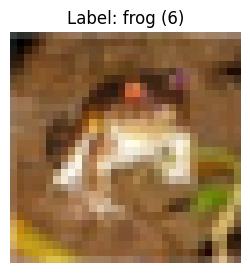

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def vec_to_img(vec3072):
    r = vec3072[0:1024].reshape(32, 32)
    g = vec3072[1024:2048].reshape(32, 32)
    b = vec3072[2048:3072].reshape(32, 32)
    img = np.dstack([r, g, b])
    return img

idx = 0
img0 = vec_to_img(X_train[idx])

plt.figure(figsize=(3,3))
plt.imshow(img0)
plt.title(f"Label: {classes[y_train[idx]]} ({y_train[idx]})")
plt.axis("off")
plt.show()


Η εικόνα ανακατασκευάστηκε σωστά από το διάνυσμα των 3072 τιμών και εμφανίζεται ως 32×32×3 με label `frog (6)`, άρα η δομή του RGB που περιγράφει το documentation εφαρμόζεται σωστά στα δεδομένα που φόρτωσα.


## CIFAR-10: Προεπεξεργασία (Scaling και PCA)

Σε αυτό το βήμα ετοιμάζω τα δεδομένα για τα μοντέλα scikit-learn.
Αρχικά εφαρμόζω scaling (StandardScaler) στα 3072 χαρακτηριστικά και στη συνέχεια PCA για να μειώσω τη διάσταση, ώστε η εκπαίδευση να είναι πιο γρήγορη και σταθερή.


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA
N_COMPONENTS = 100
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("PCA shapes:", X_train_pca.shape, X_test_pca.shape)
print("Explained variance (%):", round(pca.explained_variance_ratio_.sum() * 100, 2))


PCA shapes: (50000, 100) (10000, 100)
Explained variance (%): 89.83


Μετά το scaling εφάρμοσα PCA και μείωσα τη διάσταση από 3072 σε 100 χαρακτηριστικά ανά εικόνα, διατηρώντας το 89.83% της πληροφορίας, οπότε τα μοντέλα θα εκπαιδεύονται πιο γρήγορα.


## CIFAR-10: Σύγκριση δύο ταξινομητών στο πλήρες σύνολο (10 κλάσεις)

Σε αυτό το βήμα εκπαιδεύω δύο διαφορετικούς ταξινομητές πάνω στα PCA χαρακτηριστικά:
- LinearSVC (γραμμικό SVM)
- k-NN (k κοντινότεροι γείτονες)

Στη συνέχεια συγκρίνω την ακρίβεια (accuracy) στο test set.


In [45]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

svm_full = LinearSVC(random_state=42, dual=False)
knn_full = KNeighborsClassifier(n_neighbors=7)

models = {
    "LinearSVC": svm_full,
    "KNN(k=7)": knn_full
}

results = []
preds_full = {}

for name, mdl in models.items():
    mdl.fit(X_train_pca, y_train)
    pred = mdl.predict(X_test_pca)
    preds_full[name] = pred
    acc = accuracy_score(y_test, pred)
    results.append((name, acc))

df_full = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
df_full


,Model,Accuracy
0,LinearSVC,0.3962
1,KNN(k=7),0.3808


Στο πλήρες CIFAR-10 (10 κλάσεις) τα μοντέλα έχουν σχετικά χαμηλή ακρίβεια, με το LinearSVC να αποδίδει λίγο καλύτερα (0.396) από το k-NN (0.380), κάτι που δείχνει ότι το πρόβλημα είναι απαιτητικό με απλά χαρακτηριστικά (PCA) και κλασικούς ταξινομητές.


## CIFAR-10: Confusion Matrix (πλήρες σύνολο)

Σε αυτό το βήμα υπολογίζω το confusion matrix για το LinearSVC, ώστε να δω ποιες κλάσεις μπερδεύει συχνότερα και να καταλάβω καλύτερα τα λάθη του μοντέλου.


In [46]:
import pandas as pd
from sklearn.metrics import confusion_matrix

best_pred = preds_full["LinearSVC"]
cm = confusion_matrix(y_test, best_pred)

cm_df = pd.DataFrame(cm, index=classes, columns=classes)
cm_df.head(5)


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,481,56,23,23,14,22,30,56,218,77
automobile,62,522,13,17,10,33,44,47,90,162
bird,119,58,179,60,112,84,200,87,68,33
cat,63,94,65,185,33,181,188,54,54,83
deer,62,48,86,44,246,71,218,152,36,37


Από το confusion matrix φαίνεται ότι το LinearSVC κάνει σωστές προβλέψεις σε κάποιες κλάσεις (π.χ. airplane/automobile), αλλά μπερδεύεται αρκετά σε κλάσεις που μοιάζουν οπτικά (π.χ. cat–dog, bird–frog, deer–horse), κάτι που εξηγεί τη χαμηλή συνολική ακρίβεια.


## CIFAR-10: Πείραμα σε υποσύνολο κλάσεων

Σε αυτό το βήμα επαναλαμβάνω την κατηγοριοποίηση σε ένα υποσύνολο 4 κλάσεων, ώστε να μειώσω τη δυσκολία του προβλήματος
και να δω πώς αλλάζει η απόδοση των μοντέλων.
Επιλέγω τις κλάσεις: airplane, automobile, ship, truck (vehicles).


In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Υποσύνολο κλάσεων (vehicles)
subset_classes = [0, 1, 8, 9]  # airplane, automobile, ship, truck
subset_names = [classes[i] for i in subset_classes]

# Φιλτράρισμα train/test
train_mask = np.isin(y_train, subset_classes)
test_mask  = np.isin(y_test, subset_classes)

Xtr = X_train[train_mask]   # εδώ είναι ήδη (N,3072) από τα batches
Xte = X_test[test_mask]
ytr = y_train[train_mask]
yte = y_test[test_mask]

print("Subset train:", Xtr.shape, "Subset test:", Xte.shape)
print("Classes used:", subset_names)

# Scaling
scaler_sub = StandardScaler()
Xtr_s = scaler_sub.fit_transform(Xtr)
Xte_s = scaler_sub.transform(Xte)

# PCA
pca_sub = PCA(n_components=100, random_state=42)
Xtr_p = pca_sub.fit_transform(Xtr_s)
Xte_p = pca_sub.transform(Xte_s)

print("Explained variance (%):", round(pca_sub.explained_variance_ratio_.sum() * 100, 2))

# 2 μοντέλα
svm_sub = LinearSVC(random_state=42, dual=False)
knn_sub = KNeighborsClassifier(n_neighbors=7)

models_sub = {"LinearSVC": svm_sub, "KNN(k=7)": knn_sub}

res_sub = []
preds_sub = {}

for name, mdl in models_sub.items():
    mdl.fit(Xtr_p, ytr)
    pred = mdl.predict(Xte_p)
    preds_sub[name] = pred
    acc = accuracy_score(yte, pred)
    res_sub.append((name, acc))

df_sub = pd.DataFrame(res_sub, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
df_sub


Subset train: (20000, 3072) Subset test: (4000, 3072)
Classes used: ['airplane', 'automobile', 'ship', 'truck']
Explained variance (%): 89.68


,Model,Accuracy
0,LinearSVC,0.57750
1,KNN(k=7),0.55775


Στο υποσύνολο 4 κλάσεων (airplane, automobile, ship, truck) η ακρίβεια βελτιώνεται σημαντικά σε σχέση με το πλήρες CIFAR-10, με το LinearSVC να φτάνει περίπου  0.578 και το k-NN περίπου  0.558, κάτι που δείχνει ότι με λιγότερες κλάσεις το πρόβλημα γίνεται πιο εύκολο και τα μοντέλα γενικεύουν καλύτερα.


## CIFAR-10: Συγκριτικός πίνακας (Full vs Subset)

Σε αυτό το βήμα φτιάχνω έναν συγκριτικό πίνακα που συνοψίζει την ακρίβεια των δύο μεθόδων:
- στο πλήρες πρόβλημα (10 κλάσεις)
- στο υποσύνολο (4 κλάσεις)

Έτσι παρουσιάζω καθαρά πώς επηρεάζει η πολυπλοκότητα (αριθμός κλάσεων) την επίδοση.


In [48]:
import pandas as pd

df_full2 = df_full.copy()
df_full2["Setting"] = "Full (10 classes)"

df_sub2 = df_sub.copy()
df_sub2["Setting"] = "Subset (4 classes)"

df_compare = pd.concat([df_full2, df_sub2], ignore_index=True)
df_compare = df_compare[["Setting", "Model", "Accuracy"]].sort_values(["Setting", "Accuracy"], ascending=[True, False])

df_compare


,Setting,Model,Accuracy
0,Full (10 classes),LinearSVC,0.39620
1,Full (10 classes),KNN(k=7),0.38080
2,Subset (4 classes),LinearSVC,0.57750
3,Subset (4 classes),KNN(k=7),0.55775


Ο συγκριτικός πίνακας δείχνει καθαρά ότι και τα δύο μοντέλα αποδίδουν πολύ καλύτερα στο υποσύνολο 4 κλάσεων (0.58) σε σχέση με το πλήρες πρόβλημα 10 κλάσεων (0.39), άρα η αύξηση του αριθμού κλάσεων κάνει το CIFAR-10 σημαντικά πιο δύσκολο.


## Ερώτημα 2: Συμπέρασμα (CIFAR-10)

Στο CIFAR-10 ακολούθησα τη δομή του dataset όπως περιγράφεται στο documentation (πηγή 3),
φορτώνοντας τα `data_batch_1..5` και το `test_batch` με `pickle`, καθώς και τα ονόματα κλάσεων από το `batches.meta`.

Στη συνέχεια μετέτρεψα κάθε εικόνα σε διάνυσμα 3072 τιμών (RGB), εφάρμοσα StandardScaler και PCA (100 συνιστώσες),
και εκπαίδευσα δύο διαφορετικούς ταξινομητές (LinearSVC και k-NN).

Στο πλήρες πρόβλημα των 10 κλάσεων, η ακρίβεια ήταν σχετικά χαμηλή (0.396 για LinearSVC και 0.381 για k-NN),
γεγονός αναμενόμενο λόγω της δυσκολίας του CIFAR-10 (μικρές εικόνες και αρκετές κλάσεις με ομοιότητες).

Το confusion matrix έδειξε ότι το μοντέλο μπερδεύεται συχνά σε παρόμοιες κλάσεις (π.χ. cat–dog, bird–frog, deer–horse).

Όταν επανέλαβα το πείραμα σε υποσύνολο 4 κλάσεων (airplane, automobile, ship, truck), η ακρίβεια βελτιώθηκε σημαντικά
(0.578 για LinearSVC και 0.558 για k-NN), δείχνοντας ότι η μείωση του αριθμού κλάσεων μειώνει την πολυπλοκότητα
του προβλήματος και οδηγεί σε καλύτερη γενίκευση.

Συνολικά, το LinearSVC ήταν σταθερά το καλύτερο από τα δύο μοντέλα.
